# Decadimento RC con fit non lineare e errori sia su x che su y

## Modello fisico

Scarica di un condensatore:


$V(t) = V_0 e^{-t/RC}$


dove:
-  t: tempo (s)
-  V(t): tensione (V)
-  $V_0$: tensione iniziale (V)
-  RC: costante di tempo (s)

---

## Obiettivo
Stimare  $V_0$ e RC.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

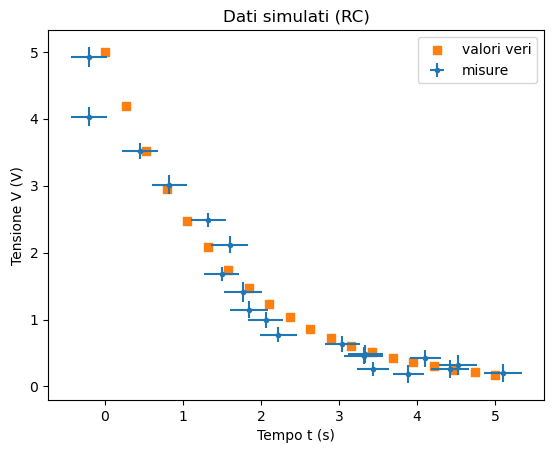

In [2]:

# parametri veri
V0_true = 5.0      # Volt
RC_true = 1.5     # secondi

# tempo vero (s)
t_true = np.linspace(0, 5, 20)

# modello ideale
V_true = V0_true * np.exp(-t_true / RC_true)

#fisso il seed in modo che i numeri casuali siano sempre gli stessi
np.random.seed(0)

# errori sperimentali
#supponiamo che ogni punto abbia un errore leggermente diverso 
#per far ciò assumo un valore di partenza e aggiungo una variazione distribuita in mniera uniforme
st = 0.2 + 0.05*np.random.uniform(size=len(t_true))  # s
sV = 0.1 + 0.05*np.random.uniform(size=len(V_true)) # V


# dati misurati: aggiungiamo alle misure vere gli errori distribuiti come 
# gaussiane con sigma date da st e sV
t = t_true + np.random.normal(0, st)
V = V_true + np.random.normal(0, sV)

plt.errorbar(t, V, xerr=st, yerr=sV, fmt='.', label='misure')
plt.scatter(t_true, V_true, marker='s', color='tab:orange',label = 'valori veri')
plt.xlabel('Tempo t (s)')
plt.ylabel('Tensione V (V)')
plt.title('Dati simulati (RC)')
plt.legend()
plt.show()


In [3]:
#faccio il fit ignorando l'errore su x

from scipy.optimize import curve_fit

def f(x, V0, RC):
    return V0 * np.exp(-x / RC)

popt, pcov = curve_fit(f, t, V, sigma=sV, absolute_sigma=True)

print("curve_fit:")
print("stima dei parametri:", popt)
print("matrice delle covarianze:", pcov)
V0_f = popt[0]
V0_s = np.sqrt(pcov[0][0])
RC_f = popt[1]
RC_s = np.sqrt(pcov[1][1])
print(f"V0 = {V0_f:.3f} ± {V0_s:.3f} V")
print(f"RC = {RC_f:.3f} ± {RC_s:.3f} s")

curve_fit:
stima dei parametri: [4.20462403 1.69668709]
matrice delle covarianze: [[ 0.0053624  -0.0017474 ]
 [-0.0017474   0.00211226]]
V0 = 4.205 ± 0.073 V
RC = 1.697 ± 0.046 s


In [4]:
#valore del chi2
residui = V - f(t, popt[0], popt[1])
chi2 = np.sum((residui / sV)**2)

ndof = len(V) - len(popt)
chi2_red = chi2 / ndof

print("chi2 =", chi2)
print("chi2 ridotto =", chi2_red)

chi2 = 117.68702750501002
chi2 ridotto = 6.538168194722779


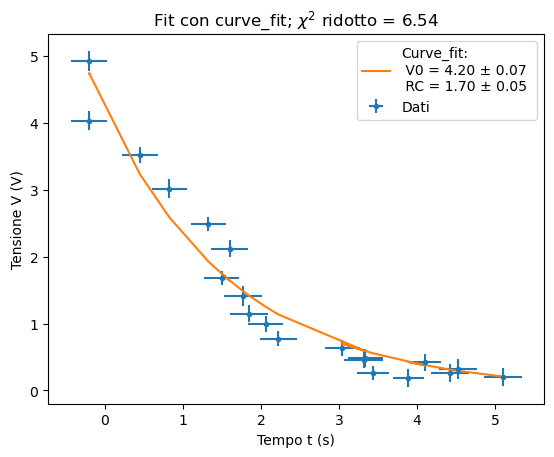

In [5]:
plt.errorbar(t, V, xerr=st, yerr=sV, fmt='.',label="Dati")
plt.plot(t,f(t,popt[0],popt[1]),
        label=f"Curve_fit:\n V0 = {V0_f:.2f} ± {V0_s:.2f}\n RC = {RC_f:.2f} ± {RC_s:.2f} ")
plt.xlabel('Tempo t (s)')
plt.ylabel('Tensione V (V)')
plt.title(f'Fit con curve_fit; $\chi^2$ ridotto = {chi2_red:.2f}')
plt.legend()
plt.show()

In [6]:
from scipy import odr

#questo metodo richiede una serie di passaggi con una sintassi specifica
#definizione della funzione di fit
def model(beta, t):
    #beta è il vettore dei parametri
    return beta[0] * np.exp(-t / beta[1])

#creazione del modello
odr_model = odr.Model(model)

#definizione dei dati
data = odr.RealData(t, V, sx=st, sy=sV)

#in questo caso è importante definire dei valori iniziali ragionevoli
#Possiamo utilizzare l'output del fit di prima
#nella sintassi di questo metodo, il vettore dei parametri si chiama beta
beta0 = [popt[0], popt[1]]

#definire una instanza di ODR (terminologia della programmazione a oggetti)
odr_instance = odr.ODR(data, odr_model, beta0=beta0)

#avviare il fit
output = odr_instance.run()

#il vettore output.beta conterrà le stime dei parametri 
print("output.beta:",output.beta)
#il vettore output.beta conterrà gli errori sulle stime dei parametri 
print("output.sd_beta:",output.sd_beta)
V0_fit, RC_fit = output.beta
V0_err, RC_err = output.sd_beta

print(f"V0 = {V0_fit:.2f} ± {V0_err:.2f} V")
print(f"RC = {RC_fit:.3f} ± {RC_err:.3f} s")


output.beta: [4.76240748 1.42116718]
output.sd_beta: [0.38309532 0.08983992]
V0 = 4.76 ± 0.38 V
RC = 1.421 ± 0.090 s


In [7]:
#chi quadro ridotto generalizzato
print(output.res_var)

1.0045218938505744


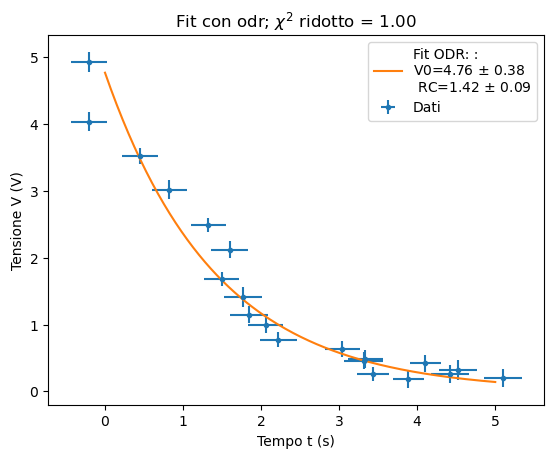

In [8]:
t_fit = np.linspace(0, 5, 200)
V_fit = model(output.beta, t_fit)

plt.errorbar(t, V, xerr=st, yerr=sV, fmt='.', label='Dati')
plt.plot(t_fit, V_fit, label=f"Fit ODR: :\nV0={V0_fit:.2f} $\pm$ {V0_err:.2f} \n RC={RC_fit:.2f} $\pm$ {RC_err:.2f}")

plt.xlabel('Tempo t (s)')
plt.ylabel('Tensione V (V)')
plt.title(f'Fit con odr; $\chi^2$ ridotto = {output.res_var:.2f}')
plt.legend()
plt.show()


In [9]:
#output aggiuntivi

#stima dell'errore su x
print("stima delta x:",output.delta)

#stima dell'errore su y
print("stima epsilon",output.eps)

chiquadro = np.sum(output.delta**2/st**2 + output.eps**2/sV**2)
print("Equivalente del chi quadro:",chiquadro)
ndf = len(st) -2
print("Numero di gradi di libertà:",ndf)
print("Stima chi quadro ridotto:",chiquadro/ndf,"vs residual variance:",output.res_var)

stima delta x: [ 0.14921854  0.42289754 -0.01469407 -0.16097964 -0.37192565 -0.3851479
 -0.00836068 -0.02861714  0.13209809  0.11267076  0.21900573 -0.02111354
 -0.06394222  0.00283665  0.13651136 -0.06794822  0.05635761 -0.0230773
 -0.04386986 -0.01918174]
stima epsilon [ 0.01839808  0.05188644 -0.00169901 -0.02868931 -0.04975697 -0.08694482
 -0.00165443 -0.01052387  0.04090129  0.04696758  0.08136414 -0.02436826
 -0.04482981  0.00237345  0.12314313 -0.14257521  0.11377168 -0.04462463
 -0.11614827 -0.06171368]
Equivalente del chi quadro: 18.081394089310347
Numero di gradi di libertà: 18
Stima chi quadro ridotto: 1.0045218938505749 vs residual variance: 1.0045218938505744
